# Combined Analysis: Reddit Sentiment vs US AI Hiring Share

## Overview

This notebook brings together two datasets that have been analyzed separately:
- **Reddit sentiment data** (2025): daily sentiment scores from 9 subreddits, broken down by subreddit and source type (posts, comments, combined)
- **Indeed AI hiring share data** (2025): daily percentage of US job postings mentioning AI as a requirement

The central question is whether public sentiment about AI on Reddit tracks actual AI hiring demand in the US labor market, and if so, which communities show the strongest signal and with what time delay.

## What this notebook covers:

1. **Finding 1: Baseline relationship**: all subreddits, posts only, no lag. Establishes the overall direction of the relationship.
2. **Finding 2: Tech community fear signal**: r/artificial, r/MachineLearning, r/datascience, r/technology with a 5-week lag. Shows practitioners react to hiring surges with delayed anxiety.
3. **Finding 3: Economics community opportunity signal** : r/Economics with a 6-week lag. Shows economists interpret the same hiring surge as a positive economic signal.
4. **Finding 4: Fear vs opportunity contrast** : side by side lagged correlation charts for tech communities vs r/Economics. The central narrative finding.

## Why weekly aggregation?

Both datasets are available at daily frequency but daily sentiment is too noisy for meaningful correlation analysis. We aggregate both to weekly (non-overlapping windows) giving 53 independent observations for 2025. This is the right balance between granularity and stability.

## Why these specific subreddits and lags?

These 4 findings were selected from a systematic sweep of 23 subreddit combinations and lags from -8 to +8 weeks. The full exploration is documented in `combined_analysis_exploration.ipynb`. The findings here represent the strongest and most interpretable correlations from that sweep.

## Data sources:
- `reddit_daily_sentiment_all.csv`: generated from `reddit_analysis_final.ipynb`
- `indeed_daily_2025.csv`: generated from `indeed_analysis_final.ipynb`

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'font.size':         11
})

# load Reddit granular sentiment data
# one row per subreddit per day per source type (posts/comments/combined)
reddit = pd.read_csv('reddit_daily_sentiment_all.csv')

# load Indeed daily AI share for 2025, US and English-speaking countries
indeed = pd.read_csv('indeed_daily_2025.csv')

reddit['date'] = pd.to_datetime(reddit['date'])
indeed['date'] = pd.to_datetime(indeed['date'])

# US only for Indeed — primary market for comparison with Reddit
us = indeed[indeed['country'] == 'United States'][['date', 'ai_share_pct']].copy()

# tech subreddits used in Finding 2
# these communities consist of practitioners who build and work with AI
TECH_SUBS = ['artificial', 'MachineLearning', 'datascience', 'technology']

print('Loaded successfully.')
print(f'Reddit shape: {reddit.shape}')
print(f'Indeed US shape: {us.shape}')
print(f'Reddit date range: {reddit["date"].min().date()} to {reddit["date"].max().date()}')
print(f'Indeed date range: {us["date"].min().date()} to {us["date"].max().date()}')

Loaded successfully.
Reddit shape: (8406, 5)
Indeed US shape: (365, 2)
Reddit date range: 2025-01-01 to 2025-12-31
Indeed date range: 2025-01-01 to 2025-12-31


## 2. Helper Functions

Two helper functions are used throughout:

`get_weekly_merged`: takes a Reddit cut, aggregates both Reddit and Indeed to weekly, optionally shifts Indeed data by a lag, and merges on date. A positive lag means Indeed data is shifted forward, so we are asking whether hiring at week T predicts sentiment at week T+lag.

`get_lagged_corrs`: computes the Pearson correlation at every lag from -8 to +8 weeks. Used for Finding 4 to identify the optimal lag for each community.

In [2]:
def get_weekly_merged(reddit_cut, lag=0):
    # aggregate Reddit cut to weekly mean sentiment
    reddit_cut = reddit_cut.copy()
    reddit_cut['week'] = reddit_cut['date'].dt.to_period('W')
    rw = (
        reddit_cut.groupby('week')['daily_sentiment_score']
        .mean().reset_index()
    )
    rw['date'] = rw['week'].dt.to_timestamp()

    # aggregate Indeed to weekly mean AI share
    uw = us.copy()
    uw['week'] = uw['date'].dt.to_period('W')
    uw = uw.groupby('week')['ai_share_pct'].mean().reset_index()
    uw['date'] = uw['week'].dt.to_timestamp()

    merged = rw.merge(uw[['date', 'ai_share_pct']], on='date', how='inner')

    # apply lag: shift Indeed data forward by lag weeks
    # this asks whether hiring at week T predicts sentiment at week T+lag
    if lag != 0:
        merged['ai_share_pct'] = merged['ai_share_pct'].shift(lag)
        merged = merged.dropna()

    return merged


def get_lagged_corrs(reddit_cut, lags=range(-8, 9)):
    # compute Pearson correlation at each lag from -8 to +8 weeks
    # negative lag = hiring leads sentiment
    # positive lag = sentiment leads hiring
    reddit_cut = reddit_cut.copy()
    reddit_cut['week'] = reddit_cut['date'].dt.to_period('W')
    rw = (
        reddit_cut.groupby('week')['daily_sentiment_score']
        .mean().reset_index()
    )
    rw['date'] = rw['week'].dt.to_timestamp()

    uw = us.copy()
    uw['week'] = uw['date'].dt.to_period('W')
    uw = uw.groupby('week')['ai_share_pct'].mean().reset_index()
    uw['date'] = uw['week'].dt.to_timestamp()

    merged = rw.merge(uw[['date', 'ai_share_pct']], on='date', how='inner')

    lag_corrs = []
    for lag in lags:
        if lag < 0:
            r = merged['ai_share_pct'].shift(-lag).corr(
                merged['daily_sentiment_score'])
        else:
            r = merged['ai_share_pct'].corr(
                merged['daily_sentiment_score'].shift(-lag))
        lag_corrs.append({'lag': lag, 'r': r})
    return pd.DataFrame(lag_corrs)


print('Helper functions defined.')

Helper functions defined.


## 3. Finding 1: Baseline Relationship

We start with the simplest possible cut: all subreddits combined, posts only, no lag applied. This establishes the baseline direction and strength of the relationship between Reddit sentiment and US AI hiring share.

We use posts only because our exploration showed posts carry a stronger signal than comments. People who write posts are making deliberate considered statements about their concerns, while comments tend to be more reactive and conversational.

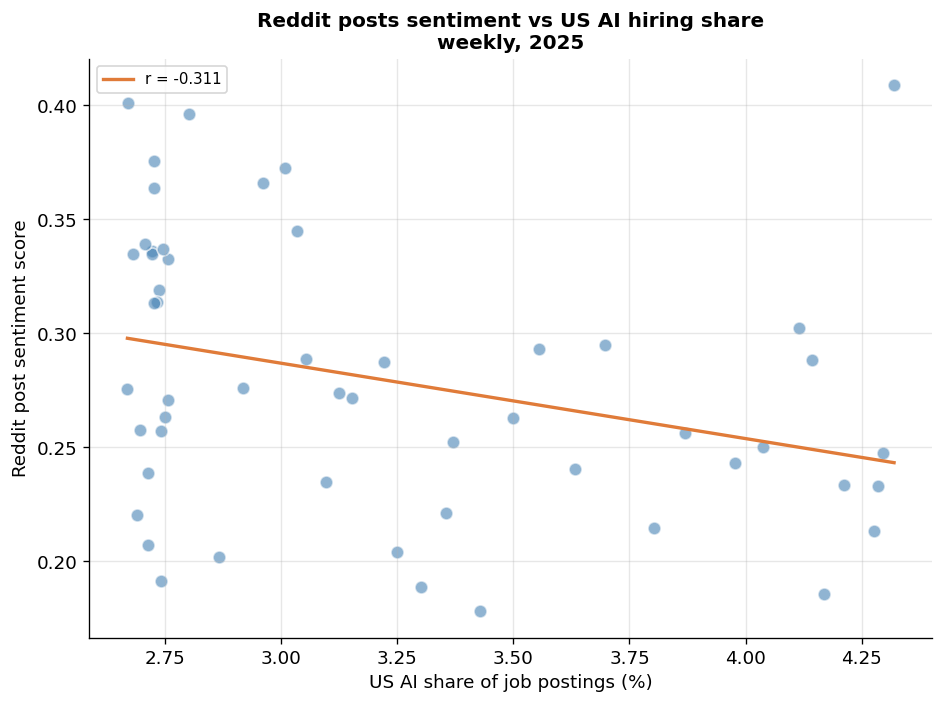

Finding 1: r = -0.311, n = 53 weeks


In [3]:
# Finding 1: all subreddits, posts only, lag 0
# baseline correlation between Reddit post sentiment and US AI hiring share

merged_base = get_weekly_merged(
    reddit[reddit['type'] == 'posts'], lag=0
)
r_base = merged_base['daily_sentiment_score'].corr(merged_base['ai_share_pct'])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(merged_base['ai_share_pct'],
           merged_base['daily_sentiment_score'],
           color='steelblue', alpha=0.6, s=60, edgecolor='white')

m, b = np.polyfit(merged_base['ai_share_pct'],
                  merged_base['daily_sentiment_score'], 1)
x_line = np.linspace(merged_base['ai_share_pct'].min(),
                     merged_base['ai_share_pct'].max(), 100)
ax.plot(x_line, m * x_line + b, color='#E07B39',
        linewidth=2, label=f'r = {r_base:.3f}')

ax.set_title('Reddit posts sentiment vs US AI hiring share\nweekly, 2025',
             fontsize=12, fontweight='bold')
ax.set_xlabel('US AI share of job postings (%)')
ax.set_ylabel('Reddit post sentiment score')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('01_baseline_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Finding 1: r = {r_base:.3f}, n = {len(merged_base)} weeks')

**Interpretation: Baseline relationship**

Each dot represents one week in 2025. The x-axis shows how much of US job postings on Indeed mentioned AI that week, and the y-axis shows the average sentiment of Reddit posts across all 9 subreddits that same week.

The trend line slopes downward with r = -0.311, meaning weeks with higher AI hiring share on Indeed tended to have slightly lower Reddit post sentiment. The relationship is weak but consistent across 53 independent weekly observations.

This is the baseline finding: as AI became more embedded in US hiring requirements through 2025, public sentiment on Reddit drifted slightly more negative. Not dramatically, but persistently.

## 4. Finding 2: Tech Community Fear Signal

The baseline uses all subreddits combined. Now we narrow to the four tech-focused communities: r/artificial, r/MachineLearning, r/datascience, and r/technology. These are communities of practitioners who build and work with AI daily. They have domain knowledge to recognize labor market shifts and may react differently from the general public.

From our exploration, the peak correlation for this group occurs at a 5-week lag, meaning AI hiring share changes in a given week are most correlated with tech community sentiment 5 weeks later. We apply this lag before computing the scatter.

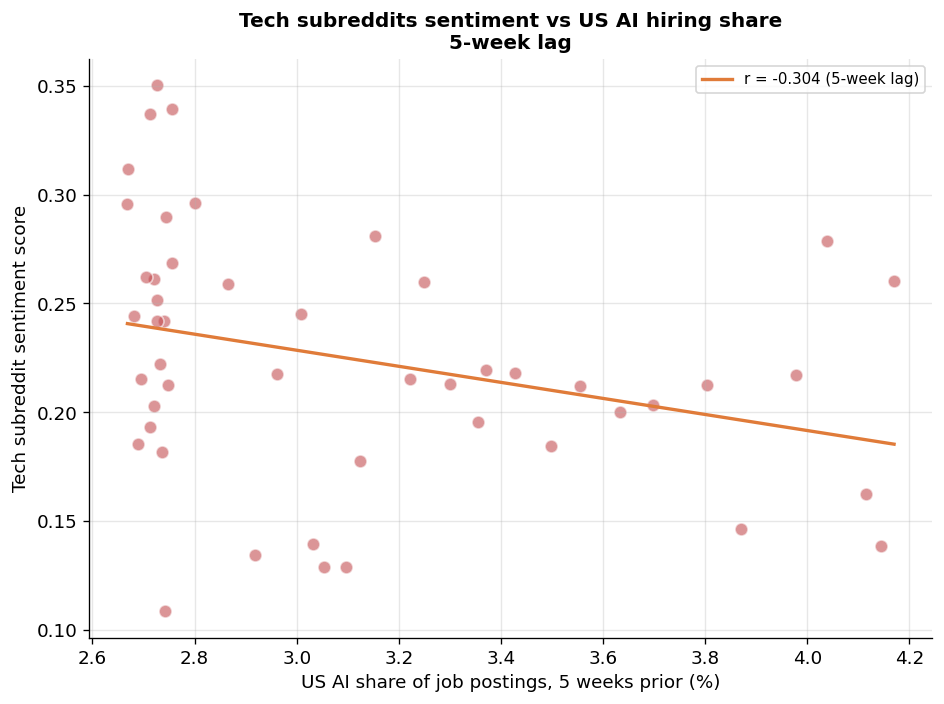

Finding 2: r = -0.304, n = 48 weeks


In [4]:
# Finding 2: tech subreddits, combined posts and comments, 5-week lag
# peak correlation from exploration sweep was -0.304 at lag -5
# meaning hiring surge at week T corresponds with lower tech sentiment at week T+5

merged_tech = get_weekly_merged(
    reddit[(reddit['subreddit'].isin(TECH_SUBS)) &
           (reddit['type'] == 'combined')],
    lag=5
)
r_tech = merged_tech['daily_sentiment_score'].corr(merged_tech['ai_share_pct'])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(merged_tech['ai_share_pct'],
           merged_tech['daily_sentiment_score'],
           color='#C44E52', alpha=0.6, s=60, edgecolor='white')

m, b = np.polyfit(merged_tech['ai_share_pct'],
                  merged_tech['daily_sentiment_score'], 1)
x_line = np.linspace(merged_tech['ai_share_pct'].min(),
                     merged_tech['ai_share_pct'].max(), 100)
ax.plot(x_line, m * x_line + b, color='#E07B39',
        linewidth=2, label=f'r = {r_tech:.3f} (5-week lag)')

ax.set_title('Tech subreddits sentiment vs US AI hiring share\n5-week lag',
             fontsize=12, fontweight='bold')
ax.set_xlabel('US AI share of job postings, 5 weeks prior (%)')
ax.set_ylabel('Tech subreddit sentiment score')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('02_tech_lag5_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Finding 2: r = {r_tech:.3f}, n = {len(merged_tech)} weeks')

**Interpretation: Tech community fear signal**

The x-axis here shows AI hiring share from 5 weeks prior. The negative slope at r = -0.304 means that when AI hiring share was high in a given week, tech community sentiment tended to be lower 5 weeks later.

The 5-week delay is meaningful. Tech practitioners do not react immediately to hiring data. But over the following weeks they see more AI requirements appearing in job postings, read industry commentary, and discuss it in their communities. The anxiety surfaces with a delay.

This finding captures the fear side of the discourse: the people most directly affected by AI hiring trends are the ones who eventually feel most anxious about them.

## 5. Finding 3: Economics Community Opportunity Signal

r/Economics is the only community in our dataset that shows a positive correlation with AI hiring share. Where tech communities become more anxious as AI hiring rises, the Economics community becomes more positive. This is the opposite reaction to the same underlying signal.

The peak correlation for r/Economics occurs at a 6-week lag.

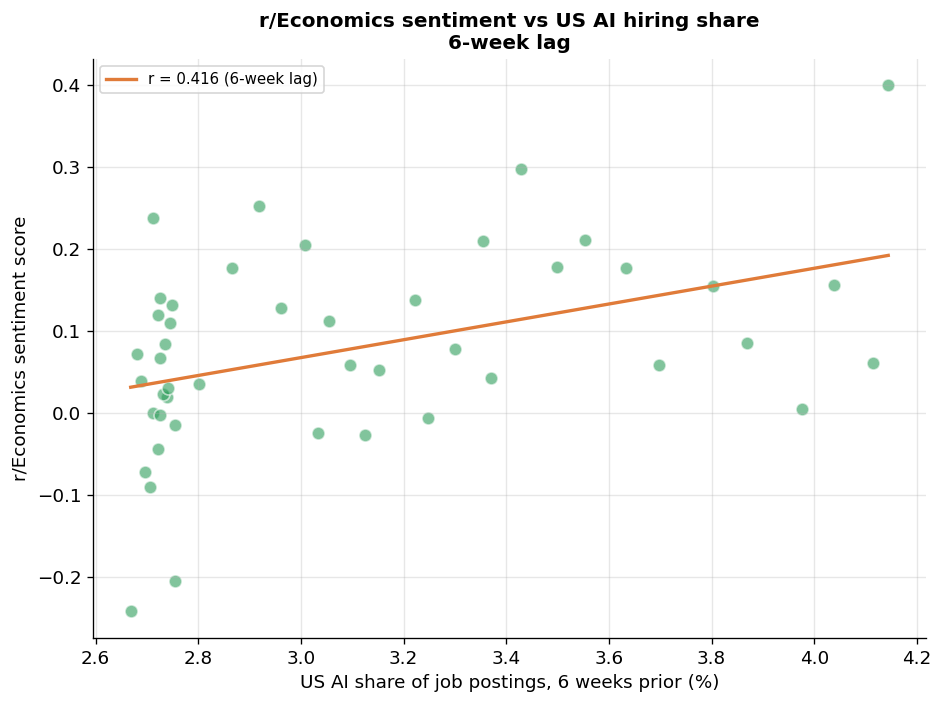

Finding 3: r = 0.416, n = 46 weeks


In [5]:
# Finding 3: r/Economics, combined, 6-week lag
# peak correlation from exploration sweep was +0.416 at lag -6
# meaning hiring surge at week T corresponds with higher Economics sentiment at week T+6
# opposite direction to tech communities

merged_econ = get_weekly_merged(
    reddit[(reddit['subreddit'] == 'Economics') &
           (reddit['type'] == 'combined')],
    lag=6
)
r_econ = merged_econ['daily_sentiment_score'].corr(merged_econ['ai_share_pct'])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(merged_econ['ai_share_pct'],
           merged_econ['daily_sentiment_score'],
           color='#2E9E5B', alpha=0.6, s=60, edgecolor='white')

m, b = np.polyfit(merged_econ['ai_share_pct'],
                  merged_econ['daily_sentiment_score'], 1)
x_line = np.linspace(merged_econ['ai_share_pct'].min(),
                     merged_econ['ai_share_pct'].max(), 100)
ax.plot(x_line, m * x_line + b, color='#E07B39',
        linewidth=2, label=f'r = {r_econ:.3f} (6-week lag)')

ax.set_title('r/Economics sentiment vs US AI hiring share\n6-week lag',
             fontsize=12, fontweight='bold')
ax.set_xlabel('US AI share of job postings, 6 weeks prior (%)')
ax.set_ylabel('r/Economics sentiment score')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('03_economics_lag6_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Finding 3: r = {r_econ:.3f}, n = {len(merged_econ)} weeks')

**Interpretation: Economics community opportunity signal**

The upward slope at r = +0.416 is the strongest correlation in this entire analysis and the only strongly positive one. When AI hiring share was high 6 weeks earlier, r/Economics sentiment tended to be higher.

Economists interpret rising AI hiring demand as a signal of productivity growth, innovation diffusion, and labor market dynamism. This is consistent with how economists generally think about technology adoption: new skill requirements in job postings signal that firms are investing in new capabilities, which is a positive macroeconomic indicator.

The 6-week lag is similar to the tech community lag of 5 weeks, suggesting both groups take roughly the same time to absorb and discuss labor market signals, just arriving at opposite conclusions.

## 6. Finding 4: Fear vs Opportunity-The Central Contrast

The most compelling finding is not any single correlation number but the contrast between the two communities. Both are responding to the same underlying signal - rising AI hiring share on Indeed, but interpreting it in completely opposite ways.

We show the full lagged correlation profile for both communities side by side, so the contrast in both direction and timing is visible.

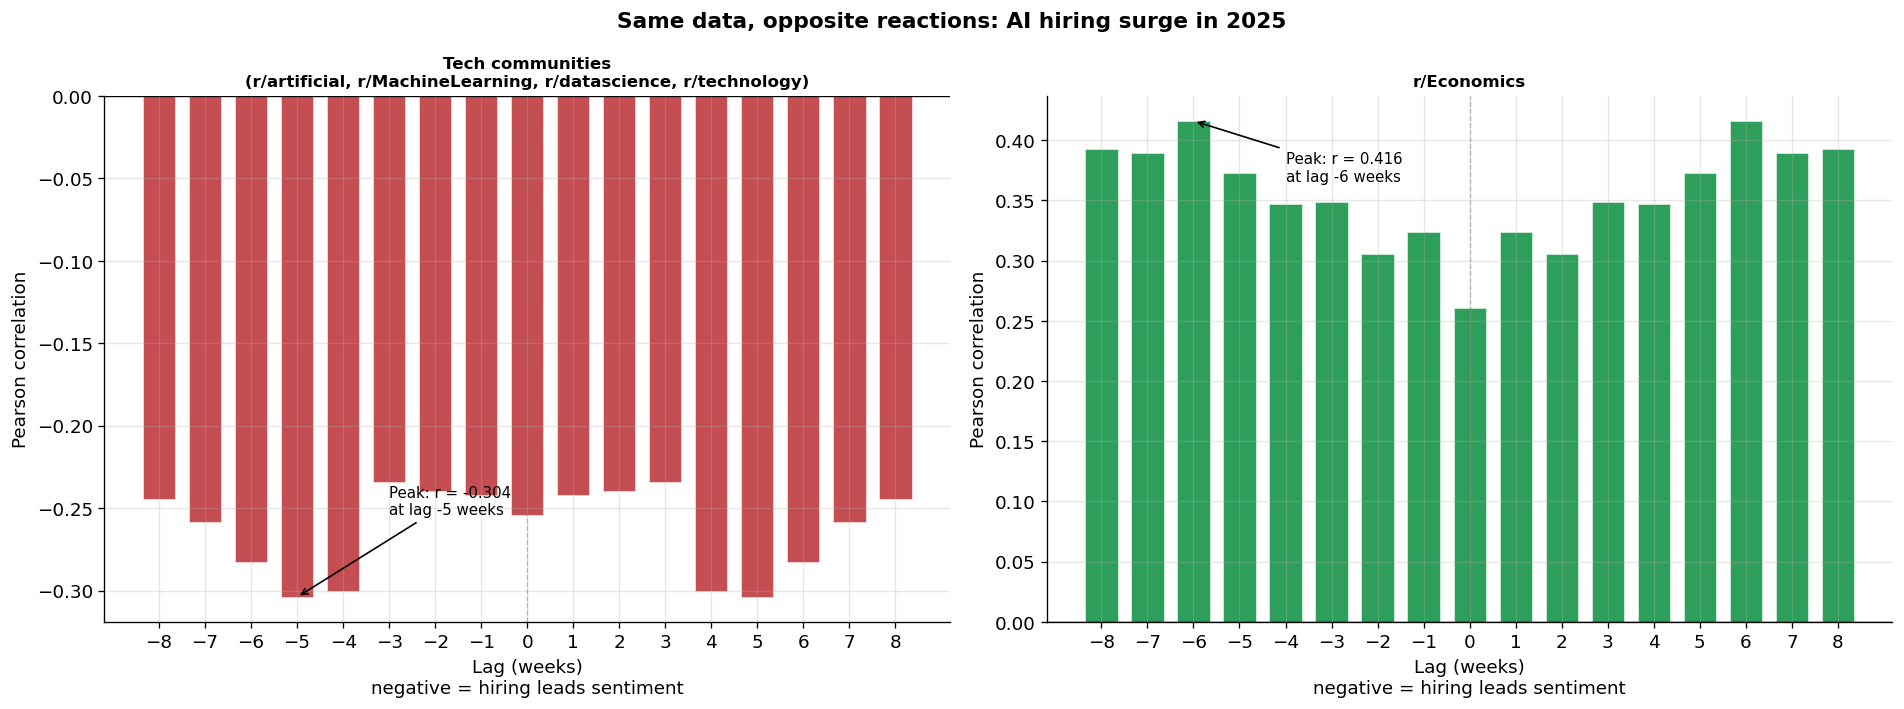

In [6]:
# Finding 4: fear vs opportunity contrast chart
# lagged correlation from -8 to +8 weeks for both communities
# left panel: tech subreddits (fear signal, peaks negative)
# right panel: r/Economics (opportunity signal, peaks positive)

tech_lags = get_lagged_corrs(
    reddit[(reddit['subreddit'].isin(TECH_SUBS)) &
           (reddit['type'] == 'combined')]
)
econ_lags = get_lagged_corrs(
    reddit[(reddit['subreddit'] == 'Economics') &
           (reddit['type'] == 'combined')]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Same data, opposite reactions: AI hiring surge in 2025',
             fontsize=13, fontweight='bold')

for ax, lag_df, title, peak_r, peak_lag in zip(
    axes,
    [tech_lags, econ_lags],
    ['Tech communities\n(r/artificial, r/MachineLearning, r/datascience, r/technology)',
     'r/Economics'],
    [-0.304, 0.416],
    [-5, -6]
):
    bar_colors = ['#C44E52' if v < 0 else '#2E9E5B' for v in lag_df['r']]
    ax.bar(lag_df['lag'], lag_df['r'],
           color=bar_colors, edgecolor='white', linewidth=0.3, width=0.7)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Lag (weeks)\nnegative = hiring leads sentiment')
    ax.set_ylabel('Pearson correlation')
    ax.set_xticks(list(range(-8, 9)))

    # mark the peak lag with an annotation
    ax.annotate(
        f'Peak: r = {peak_r}\nat lag {peak_lag} weeks',
        xy=(peak_lag, peak_r),
        xytext=(peak_lag + 2, peak_r + (0.05 if peak_r < 0 else -0.05)),
        fontsize=9,
        arrowprops=dict(arrowstyle='->', color='black', lw=1),
        color='black'
    )

plt.tight_layout()
plt.savefig('04_fear_vs_opportunity.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretation: Fear vs opportunity**

This chart captures the central finding of the combined analysis in a single view.

The left panel shows tech communities. The bars are predominantly red (negative correlation) and peak at lag -5, meaning AI hiring share 5 weeks earlier is associated with lower sentiment in these communities. The more AI becomes embedded in hiring requirements, the more anxious tech practitioners become.

The right panel shows r/Economics. The bars are predominantly green (positive correlation) and peak at lag -6. The more AI becomes embedded in hiring, the more positive economists are about it.

Both communities are reacting to the same underlying signal from the same dataset. The difference is entirely in interpretation. Tech practitioners feel the personal cost of AI skill requirements expanding. Economists read the same trend as evidence of productivity-enhancing technology diffusion.

This divergence mirrors the broader public debate around AI: whether it represents opportunity or displacement depends entirely on where you sit in the economy.

## 7. Summary of Findings

| Finding | Reddit cut | r | Lag | Interpretation |
|---------|-----------|---|-----|----------------|
| Baseline | All subreddits, posts only | -0.311 | 0 weeks | Posts consistently track hiring negatively |
| Tech fear | Tech subreddits, combined | -0.304 | -5 weeks | Practitioners anxious with 5-week delay |
| Econ opportunity | r/Economics, combined | +0.416 | -6 weeks | Economists optimistic with 6-week delay |
| Contrast | Tech vs Economics lagged | | | Same signal, opposite reactions |

**Key takeaway:**
Public sentiment and AI hiring demand do not move in lockstep at the aggregate level, but when examined at the subreddit level with appropriate lags, meaningful patterns emerge. The overall direction is negative (more AI hiring corresponds with slightly lower sentiment) but this masks a fundamental divide between how practitioners and economists interpret the same labor market signal.

**Limitations:**
- n = 53 weekly observations limits statistical confidence
- Reddit communities are self-selected and may not represent broader public opinion
- Correlation does not imply causation
- Indeed data represents one platform only, not the full job market
- A longer time series would strengthen these findings considerably

## Summary of Outputs

| File | Contents |
|------|----------|
| `01_baseline_scatter.png` | All subreddits posts vs US AI hiring, lag 0 |
| `02_tech_lag5_scatter.png` | Tech subreddits vs US AI hiring, 5-week lag |
| `03_economics_lag6_scatter.png` | r/Economics vs US AI hiring, 6-week lag |
| `04_fear_vs_opportunity.png` | Side by side lagged correlation: tech vs economics |